# Routed ZZZX Lattice Surgery

-- `UnrotatedRoutedMultiPatchCoupler`

This notebook follows the basis-aware routed surgery design:

- First infer which logical basis is actually attached to the ancillary patch region.
- Apply logical H only when the target Pauli differs from that interface basis.
- For true X/Z mixed interfaces, generate local mixed templates at seams/corners instead of assuming every stabilizer has the same type or weight.
- Use full-width routed ancillary geometry for layout, but interpret the logical product through the local green/merge checks: boundary checks on the measured merge surface are truncated instead of using ancillary data readout or known-initialization factors.
- Diagnose whether the measured merge-check outcomes generate the requested Pauli product modulo original code stabilizers. No high-weight closure syndrome is used here.

Exp 1 shows the native mixed-interface `ZZZX` full ancillary-patch geometry and the green-check product. Exp 2 shows the two-patch native `X1Z2` case.



In [52]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath('../..'))

# Reload local modules so a long-lived VS Code kernel does not keep stale classes.
import lightstim.qec_code.surface_code.unrotated.multi_patch_coupler as _multi_patch_coupler
import lightstim.qec_code.surface_code.unrotated.SE_block as _se_block
import lightstim.protocols.routed_multi_patch_ls as _routed_ls
importlib.reload(_multi_patch_coupler)
importlib.reload(_se_block)
importlib.reload(_routed_ls)

from lightstim.qec_code.surface_code.unrotated.code_patch import UnrotatedSurfaceCode
from lightstim.qec_code.surface_code.unrotated.SE_block import UnrotatedSurfaceCodeExtractionBlock
from lightstim.qec_code.surface_code.unrotated.multi_patch_coupler import UnrotatedRoutedMultiPatchCoupler
from lightstim.ir.qec_system import QECSystem
from lightstim.ir.builder import CircuitBuilder
from lightstim.ir.tracker import SyndromeTracker
from lightstim.protocols.routed_multi_patch_ls import (
    basis_change_indices_for_interfaces,
    infer_interface_paulis,
    routed_coupler_data_basis,
    solve_routed_pauli_product_merge_checks,
    solve_routed_pauli_product_syndromes,
)


def make_system(d=3):
    layout = [
        ('p1', (0, 0)),
        ('p2', (20, 0)),
        ('p3', (10, 20)),
        ('p4', (30, 20)),
    ]
    system = QECSystem()
    for name, off in layout:
        system.add_patch(UnrotatedSurfaceCode(distance=d), name=name, offset=off)
    return system


patch_names = ['p1', 'p2', 'p3', 'p4']
target_paulis = 'ZZZX'



---

## Exp 1: native mixed-interface ZZZX full ancillary patch

Here the selected sides attach to the ancillary patch with edge bases `Z, Z, Z, X`, so no logical H is needed. The routed coupler is built with `mixed_stabilizers=True` and `route_width = 2*d - 1`. Here `d` is the code distance, while `route_width` is the integer-coordinate span of one unrotated patch block: along one edge the `d` data qubits sit every two coordinates, with syndrome coordinates between them, so the inclusive coordinate span is `2*(d-1)+1 = 2*d - 1`.

The product measurement below uses the green-check interpretation: only the selected local merge checks contribute to the measured outcome. The original code stabilizers are allowed as algebraic equivalences because they are +1 in the code space, but they are not multiplied as new measurement outcomes. Ancillary boundary data that previously appeared as `known init terms` are now treated as the outside of the measured merge surface, so the corresponding local checks are truncated to weight 2/3/4.



ancilla-attached edge bases: ['Z', 'Z', 'Z', 'X']
H indices: []
mixed-template types: {'Z': 84, 'X': 76, 'MIXED': 5}
mixed-template weights: {3: 48, 2: 3, 4: 114}
route_width: 5
conflicting patch stabilizers paused: 10

static ancillary patch geometry / stabilizer-type map:


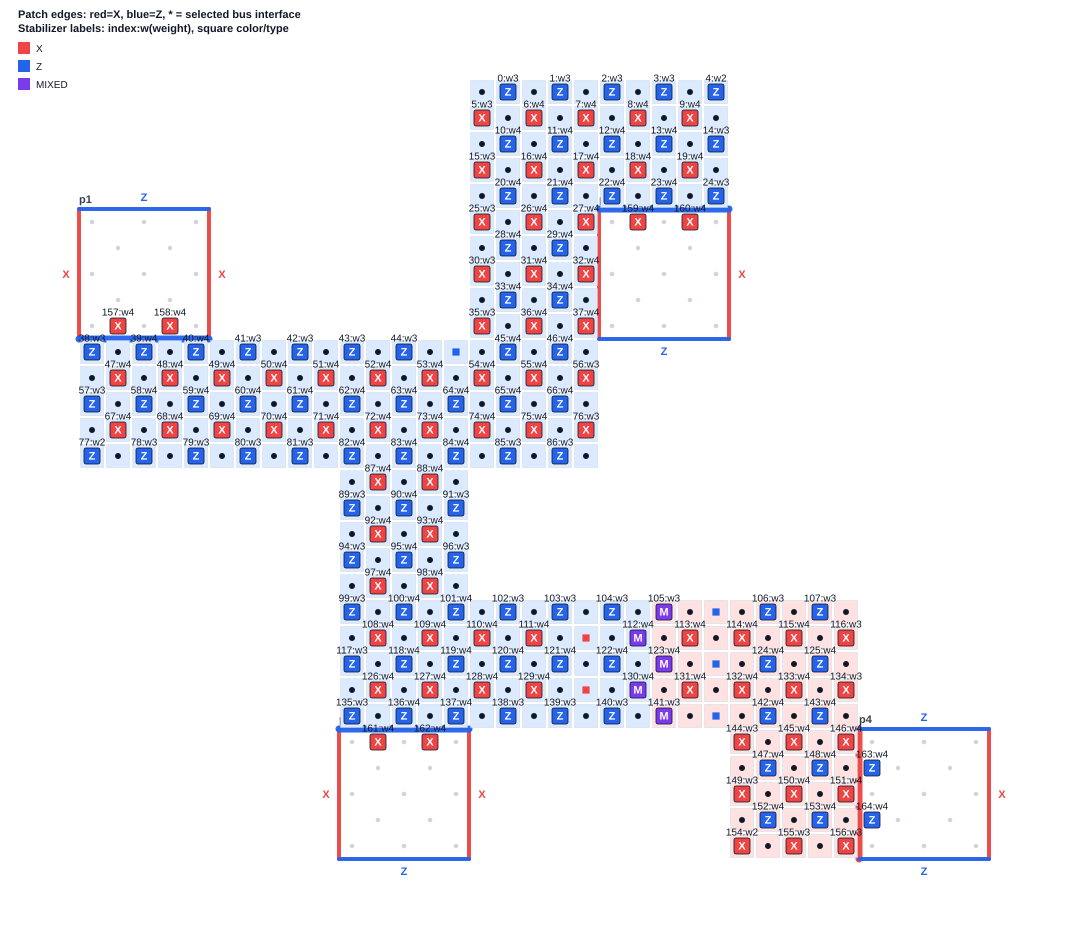


full ancillary-patch stabilizer-span diagnostic:
  verified: False
  failure: full-patch stabilizer span leaves ancillary boundary factors

green merge-check product decomposition:
  verified: True
  measured green checks: 20
  green-check weights: {2: 9, 3: 10, 4: 1}
  original patch stabilizer equivalence terms: 6
  ancillary data readout terms: 0
  known ancillary initialization outcome terms: 0

full detector/observable circuit:
  skipped: native full-width mixed-interface tracker/DEM schedule is not yet complete for these trimmed green checks


In [53]:
d = 3
system = make_system(d)
mixed_sides = ['bottom', 'top', 'top', 'left']
ancilla_attached_edge_bases = infer_interface_paulis(system, patch_names, mixed_sides)
print(f'ancilla-attached edge bases: {ancilla_attached_edge_bases}')
print(f'H indices: {basis_change_indices_for_interfaces(target_paulis, ancilla_attached_edge_bases)}')

system.register_coupler(
    UnrotatedRoutedMultiPatchCoupler(), patch_names, 'mixed_geom',
    sides=mixed_sides,
    interface_paulis=ancilla_attached_edge_bases,
    target_paulis=list(target_paulis),
    mixed_stabilizers=True,
    route_padding=8,
    route_width=2 * d - 1,
)
cp = system.coupler_patches['mixed_geom']
counts = {}
weights = {}
for stab in cp.stabilizers:
    counts[stab['type']] = counts.get(stab['type'], 0) + 1
    weights[len(stab['pauli'])] = weights.get(len(stab['pauli']), 0) + 1
print(f'mixed-template types: {counts}')
print(f'mixed-template weights: {weights}')
print(f'route_width: {cp.route_width}')
print(f'conflicting patch stabilizers paused: {len(cp.conflicting_stabilizer_coords)}')

from IPython.display import SVG, display

def render_stabilizer_type_map(system, coupler_name, patch_names, selected_sides=None):
    cp = system.coupler_patches[coupler_name]
    patch_items = [(name, system.patches[name][0]) for name in patch_names]
    selected_side_by_patch = dict(zip(patch_names, selected_sides or []))
    coords = []
    for _, patch in patch_items:
        coords.extend(patch.index_map.keys())
    coords.extend(cp.index_map.keys())
    coords.extend(cp.route_coord_basis.keys())
    coords.extend(stab['syn_coord'] for stab in cp.stabilizers)
    min_x, max_x = min(x for x, _ in coords) - 2, max(x for x, _ in coords) + 2
    min_y, max_y = min(y for _, y in coords) - 2, max(y for _, y in coords) + 2
    scale = 26
    pad = 40
    width = int((max_x - min_x) * scale + 2 * pad)
    height = int((max_y - min_y) * scale + 2 * pad)

    def xy(coord):
        return pad + (coord[0] - min_x) * scale, pad + (coord[1] - min_y) * scale

    pieces = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<style>text{font-family:Arial, sans-serif;} .small{font-size:10px;} .label{font-size:11px;font-weight:700;}</style>',
    ]

    for name, patch in patch_items:
        x0, x1, y0, y1 = patch._get_bounds()
        rx0, ry0 = xy((x0 - 0.5, y0 - 0.5))
        rx1, ry1 = xy((x1 + 0.5, y1 + 0.5))
        pieces.append(f'<rect x="{rx0:.1f}" y="{ry0:.1f}" width="{rx1-rx0:.1f}" height="{ry1-ry0:.1f}" fill="none" stroke="#9ca3af" stroke-width="1.4"/>')
        pieces.append(f'<text x="{rx0:.1f}" y="{ry0-6:.1f}" class="label" fill="#374151">{name}</text>')
        edge_specs = {
            'left': ((x0 - 0.5, y0 - 0.5), (x0 - 0.5, y1 + 0.5), (-13, 4)),
            'right': ((x1 + 0.5, y0 - 0.5), (x1 + 0.5, y1 + 0.5), (13, 4)),
            'top': ((x0 - 0.5, y0 - 0.5), (x1 + 0.5, y0 - 0.5), (0, -8)),
            'bottom': ((x0 - 0.5, y1 + 0.5), (x1 + 0.5, y1 + 0.5), (0, 16)),
        }
        for side, (start, end, label_offset) in edge_specs.items():
            basis = UnrotatedRoutedMultiPatchCoupler.infer_side_basis(patch, side)
            color = '#ef4444' if basis == 'X' else '#2563eb'
            sx, sy = xy(start)
            ex, ey = xy(end)
            selected = selected_side_by_patch.get(name) == side
            stroke = 7 if selected else 4
            pieces.append(f'<line x1="{sx:.1f}" y1="{sy:.1f}" x2="{ex:.1f}" y2="{ey:.1f}" stroke="{color}" stroke-width="{stroke}" stroke-linecap="round" opacity="0.95"/>')
            lx, ly = (sx + ex) / 2 + label_offset[0], (sy + ey) / 2 + label_offset[1]
            label = f'{basis}*' if selected else basis
            pieces.append(f'<text x="{lx:.1f}" y="{ly:.1f}" class="label" text-anchor="middle" fill="{color}">{label}</text>')
        for coord in sorted(patch.data_coords):
            x, y = xy(coord)
            pieces.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="2.3" fill="#d1d5db"/>')

    route_colors = {'X': '#fee2e2', 'Z': '#dbeafe'}
    cell_size = scale * 0.88
    for coord, basis in sorted(cp.route_coord_basis.items(), key=lambda kv: (kv[0][1], kv[0][0])):
        x, y = xy(coord)
        pieces.append(f'<rect x="{x-cell_size/2:.1f}" y="{y-cell_size/2:.1f}" width="{cell_size:.1f}" height="{cell_size:.1f}" fill="{route_colors.get(basis, "#f3f4f6")}" stroke="#cbd5e1" stroke-width="0.45"/>')

    for uid in sorted(cp.data_indices):
        x, y = xy(cp.qubit_coords[uid])
        pieces.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="3.0" fill="#111827"/>')
    for uid in sorted(cp.syndrome_indices_x):
        x, y = xy(cp.qubit_coords[uid])
        pieces.append(f'<rect x="{x-3.6:.1f}" y="{y-3.6:.1f}" width="7.2" height="7.2" fill="#ef4444"/>')
    for uid in sorted(cp.syndrome_indices_z):
        x, y = xy(cp.qubit_coords[uid])
        pieces.append(f'<rect x="{x-3.6:.1f}" y="{y-3.6:.1f}" width="7.2" height="7.2" fill="#2563eb"/>')

    typed = sorted(
        enumerate(cp.stabilizers),
        key=lambda item: (item[1]['syn_coord'][1], item[1]['syn_coord'][0], item[0]),
    )
    stab_colors = {'X': '#ef4444', 'Z': '#2563eb', 'MIXED': '#7c3aed'}
    for stab_idx, stab in typed:
        x, y = xy(stab['syn_coord'])
        stype = stab['type']
        short = 'M' if stype == 'MIXED' else stype
        weight = len(stab['pauli'])
        pieces.append(f'<rect x="{x-8:.1f}" y="{y-8:.1f}" width="16" height="16" rx="2" fill="{stab_colors[stype]}" stroke="#111827" stroke-width="0.8"/>')
        pieces.append(f'<text x="{x:.1f}" y="{y+3.6:.1f}" class="label" text-anchor="middle" fill="white">{short}</text>')
        pieces.append(f'<text x="{x:.1f}" y="{y-10.5:.1f}" class="small" text-anchor="middle" fill="#111827">{stab_idx}:w{weight}</text>')

    legend_x, legend_y = 18, 18
    pieces.append(f'<text x="{legend_x}" y="{legend_y}" class="label" fill="#111827">Patch edges: red=X, blue=Z, * = selected bus interface</text>')
    pieces.append(f'<text x="{legend_x}" y="{legend_y + 14}" class="label" fill="#111827">Stabilizer labels: index:w(weight), square color/type</text>')
    for offset, (stype, color) in enumerate(stab_colors.items()):
        y = legend_y + 34 + 18 * offset
        pieces.append(f'<rect x="{legend_x}" y="{y-10}" width="12" height="12" fill="{color}"/>')
        pieces.append(f'<text x="{legend_x+18}" y="{y}" class="small" fill="#111827">{stype}</text>')
    pieces.append('</svg>')
    return ''.join(pieces)

tracker_prep_basis = routed_coupler_data_basis(system, 'mixed_geom', mode='opposite')
try:
    zzzx_full_patch_span = solve_routed_pauli_product_syndromes(
        system=system,
        patch_names=patch_names,
        paulis=target_paulis,
        coupler_name='mixed_geom',
        include_ancilla_readout_terms=False,
    )
    zzzx_full_patch_span_error = None
except ValueError as exc:
    zzzx_full_patch_span = None
    zzzx_full_patch_span_error = str(exc)

zzzx_merge_decomp = solve_routed_pauli_product_merge_checks(
    system=system,
    patch_names=patch_names,
    paulis=target_paulis,
    coupler_name='mixed_geom',
)
merge_weights = {}
for term in zzzx_merge_decomp.selected_merge_terms:
    merge_weights[term.weight] = merge_weights.get(term.weight, 0) + 1

print('\nstatic ancillary patch geometry / stabilizer-type map:')
display(SVG(render_stabilizer_type_map(
    system, 'mixed_geom', patch_names, mixed_sides,
)))

print('\nfull ancillary-patch stabilizer-span diagnostic:')
print(f'  verified: {zzzx_full_patch_span is not None and zzzx_full_patch_span.verified}')
if zzzx_full_patch_span_error:
    print('  failure: full-patch stabilizer span leaves ancillary boundary factors')
else:
    print(f'  syndrome terms: {len(zzzx_full_patch_span.selected_terms)}')

print('\ngreen merge-check product decomposition:')
print(f'  verified: {zzzx_merge_decomp.verified}')
print(f'  measured green checks: {len(zzzx_merge_decomp.selected_merge_terms)}')
print(f'  green-check weights: {merge_weights}')
print(f'  original patch stabilizer equivalence terms: {len(zzzx_merge_decomp.patch_correction_terms)}')
print('  ancillary data readout terms: 0')
print('  known ancillary initialization outcome terms: 0')

print('\nfull detector/observable circuit:')
print('  skipped: native full-width mixed-interface tracker/DEM schedule is not yet complete for these trimmed green checks')



---

## Exp 2: full ancillary patch X1Z2 product algebra and static template

This is the two-patch native mixed-interface case on the same coarse-grid rule: `p1` connects through an `X` boundary and `p2` connects through a `Z` boundary. In this geometry the local syndrome product closes algebraically without ancillary data readout and without known initialization factors. The cell shows the static ancillary-patch/stabilizer-type map and the syndrome-product result. The full native mixed-interface tracker schedule is still diagnostic-only here, so this experiment does not render a detector/observable `detslice` diagram.



route_width: 5
interface paulis: ['X', 'Z']
prep basis counts: {'X': 16, 'Z': 21}
route-label basis counts: {'X': 21, 'Z': 16}
verified: True
syndrome terms: 30
ancilla data readout terms: 0

static ancillary patch geometry / stabilizer-type map:


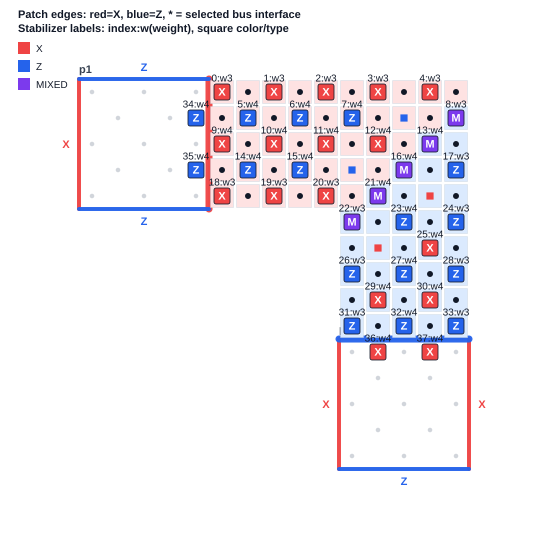


full X1Z2 detector/observable circuit:
  skipped: native mixed-interface tracker schedule is not yet complete for this geometry


In [54]:
from IPython.display import SVG, display

xz_patch_names = ['p1', 'p2']
xz_sides = ['right', 'top']
xz_target_paulis = 'XZ'

xz_system = QECSystem()
xz_system.add_patch(UnrotatedSurfaceCode(distance=3), name='p1', offset=(0, 0))
xz_system.add_patch(UnrotatedSurfaceCode(distance=3), name='p2', offset=(10, 10))
xz_system.register_coupler(
    UnrotatedRoutedMultiPatchCoupler(), xz_patch_names, 'xz',
    sides=xz_sides,
    interface_paulis=['X', 'Z'],
    target_paulis=list(xz_target_paulis),
    mixed_stabilizers=True,
    route_padding=8,
    route_width=2 * 3 - 1,
)

xz_prep_basis = routed_coupler_data_basis(xz_system, 'xz', mode='opposite')
xz_residual_route_basis = routed_coupler_data_basis(xz_system, 'xz', mode='same')
xz_decomp = solve_routed_pauli_product_syndromes(
    system=xz_system,
    patch_names=xz_patch_names,
    paulis=xz_target_paulis,
    coupler_name='xz',
    include_ancilla_readout_terms=False,
)

print(f'route_width: {xz_system.coupler_patches["xz"].route_width}')
print('interface paulis:', ['X', 'Z'])
print('prep basis counts:', {b: list(xz_prep_basis.values()).count(b) for b in ['X', 'Z']})
print('route-label basis counts:', {b: list(xz_residual_route_basis.values()).count(b) for b in ['X', 'Z']})
print(f'verified: {xz_decomp.verified}')
print(f'syndrome terms: {len(xz_decomp.selected_terms)}')
print(f'ancilla data readout terms: {len(xz_decomp.selected_ancilla_terms)}')

print('\nstatic ancillary patch geometry / stabilizer-type map:')
display(SVG(render_stabilizer_type_map(
    xz_system, 'xz', xz_patch_names, xz_sides,
)))

print('\nfull X1Z2 detector/observable circuit:')
print('  skipped: native mixed-interface tracker schedule is not yet complete for this geometry')
